# 01 — Heston, calibrated by MCMC

**Phase 1, deliverable 2** (`PROJECT_PLAN.md` §4). This is the **v0 baseline**: the classical model
that the flow-matching neural SDE of Phase 2 will have to beat, scored through the *same*
`src/eval` harness so the comparison is honest (§8: *"every method is evaluated identically"*).

Calibration is two-stage: bounded least-squares on implied-vol residuals for a point estimate, then
**numpyro NUTS** warm-started there for the full posterior. The posterior is the point of using MCMC
at all, so it is reported — R-hat, ESS, divergences, credible intervals — rather than being collapsed
to its mean and thrown away.

Everything lands as a row in `reports/benchmark.md`.

In [1]:
import os
import sys
from pathlib import Path

# numpyro runs its 4 chains sequentially unless XLA is told there are 4 devices. This MUST run
# before jax is imported anywhere, hence its own cell at the top.
os.environ["XLA_FLAGS"] = "--xla_force_host_platform_device_count=4"

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import jax
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("jax devices:", jax.local_device_count())

jax devices: 4


In [2]:
from src.algorithms.black_scholes import implied_vol
from src.algorithms.heston.heston_analytics import HestonModel
from src.algorithms.heston.heston_config import (
    HestonCalibrationConfig,
    MCConfig,
    NUTSConfig,
    QuadConfig,
)
from src.algorithms.heston.heston_mc import HestonSimulator
from src.algorithms.heston.heston_params import HestonParams
from src.algorithms.preprocessing import (
    LiquidityConfig,
    PreprocessConfig,
    SurfacePreprocessor,
    implied_rate,
)
from src.data.data_loader import DataLoader
from src.eval.benchmark import BenchmarkTable, build_row
from src.eval.eval_config import BenchmarkConfig
from src.eval.metrics import (
    marginal_report,
    martingale_residual,
    mc_call_prices,
    mc_pricing_error,
    surface_rmse,
)
from src.eval.plots import (
    plot_mc_prices,
    plot_paths_density,
    plot_posterior,
    plot_smile_fit,
)
from src.eval.surface import split_wings, svi_iv_rmse

pd.set_option("display.precision", 4)

/Users/lama/Developer/side/QuantFlow/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. The cleaned surface

Same pipeline as notebook 00. Strikes are restricted to 0.80–1.20 of spot: Heston is a
five-parameter model and cannot fit the deep wings anyway, so including them would just let the far
OTM puts dominate the least-squares objective.

In [3]:
chain = DataLoader().load_parquet(str(ROOT / "data/spx_option_chain.parquet"))
chain = chain[chain.ttm > 0].copy()

s0 = float(chain.spot.iloc[0])
snapshot = str(pd.to_datetime(chain.snapshot_time.iloc[0]).date())
r = implied_rate(chain)

cfg = PreprocessConfig(
    liquidity=LiquidityConfig(min_volume=0, min_open_interest=1, max_rel_spread=0.05))
pre = SurfacePreprocessor(cfg)
surface = pre.prepare(chain, r=r)

clean = surface.clean
clean = clean[clean.strike.between(0.80 * s0, 1.20 * s0)].reset_index(drop=True)

print(f"snapshot={snapshot}  s0={s0:.1f}  r={r:.4f}")
print(f"quotes={len(clean)}  maturities={clean.ttm.nunique()}")

snapshot=2026-06-16  s0=7511.6  r=0.0573
quotes=690  maturities=8


## 2. Hold out the wings

`PROJECT_PLAN.md` §8 asks for *"implied vol RMSE on held-out wing of strikes"*, and nothing in the
pipeline provided it — every number reported before now was in-sample.

The split is **per maturity**: within each slice, the quarter of quotes furthest from the money are
held out. (A *global* split would hand the model whole maturities it never saw, which measures
term-structure extrapolation — a different question.)

Expect the held-out number to be **worse** than the in-sample one. That is the point of measuring it.

One honest caveat: SVI and the BL marginals are fitted on the *full* surface. SVI is the market
interpolant, not a model under test, so "held out" here means held out from **Heston**, not from
everything.

In [4]:
split = split_wings(clean)
train, test = split.train, split.test

print(f"train (fit on)      : {len(train)} quotes")
print(f"test  (held-out wing): {len(test)} quotes")
print(f"|log-moneyness| — train max {train.log_moneyness.abs().max():.3f}, "
      f"test min {test.log_moneyness.abs().min():.3f}")

train (fit on)      : 514 quotes
test  (held-out wing): 176 quotes
|log-moneyness| — train max 0.164, test min 0.046


## 3. Sanity-check the reference pricer *before* trusting it

The MC-pricing-error metric below compares the Monte-Carlo simulator against `HestonModel.call`, the
"exact" Fourier price. But that price is itself a Gauss–Legendre quadrature **truncated at
$u_{\max}$** — and if it has not converged, the metric measures the *pricer*, not the simulator.

This is not hypothetical. The Heston characteristic function decays like
$\exp(-c\,v\,T\,u^2)$, so the **short** end is what strains the truncation, not the long end. The
inherited default $(u_{\max}=200,\ n=128)$ turns out to be badly unconverged there:

| $T$ | error of $(200, 128)$ | error of $(800, 256)$ |
|---|---|---|
| 0.017 | **0.63** (absolute, in index points) | 1.2e-05 |
| 0.14 | 0.081 | 1.6e-08 |
| 1.00 | 1.6e-07 | 4.7e-08 |

A 0.63 price error at the short end flows straight into the **calibration objective** and then
reappears as fake "model error" in any MC comparison. `QuadConfig` now defaults to
$(u_{\max}=800,\ n=256)$. Verify it against a gold-standard grid before relying on it:

In [5]:
probe = HestonParams(v_0=0.02, v_mean=0.12, a=0.92, eta=0.97, rho=-0.73)  # a rough SPX-like slice
k_probe = np.array([0.9 * s0, s0, 1.1 * s0])

gold = HestonModel(probe, HestonCalibrationConfig(quad=QuadConfig(u_max=3000, n_quad=2048)))
default = HestonModel(probe)   # the shipped default

for ttm in (0.017, 0.14, 1.0):
    t = np.full_like(k_probe, ttm)
    err = np.abs(default.call(k_probe, s0, r, t) - gold.call(k_probe, s0, r, t)).max()
    print(f"T={ttm:5.3f}  max |default - gold| = {err:.2e}  "
          f"{'converged' if err < 1e-3 else 'NOT CONVERGED — metric unsafe'}")

Bad value of the params: Feller condition isnt satisfied.
Bad value of the params: Feller condition isnt satisfied.


T=0.017  max |default - gold| = 1.45e-05  converged
T=0.140  max |default - gold| = 7.94e-09  converged
T=1.000  max |default - gold| = 4.31e-08  converged


## 4. Calibrate — least squares, then NUTS

`optimize_params` runs both stages: `scipy.least_squares` on IV residuals for a point estimate, then
NUTS warm-started there with priors centred on it. The likelihood uses **vega-weighted price**
errors rather than IV residuals directly — a Brent inversion is not differentiable, and
$(\text{model} - \text{market})/\text{vega}$ is a first-order approximation to an IV residual that
autodiff can get through.

Fit is on `train` only, with the converged quadrature from §3.

In [6]:
init = HestonParams(v_0=0.04, v_mean=0.04, a=2.0, eta=0.5, rho=-0.7)
calib_cfg = HestonCalibrationConfig(
    nuts=NUTSConfig(num_warmup=400, num_samples=400, num_chains=4, seed=0),
)
model = HestonModel(init, calib_cfg)

model.optimize_params(k=train.strike.to_numpy(), s_0=s0, r=r,
                      t=train.ttm.to_numpy(), call=train.call_price.to_numpy())

fitted = model.params
print(fitted)
print(f"\nFeller 2*a*v_mean >= eta^2 : "
      f"{2 * fitted.a * fitted.v_mean:.3f} >= {fitted.eta ** 2:.3f}  ->  {fitted.feller()}")

Bad value of the params: Feller condition isnt satisfied.


HestonParams(v_0=0.02029199409418167, v_mean=0.11959543807440164, a=0.9409443063725762, eta=0.9730366233448247, rho=-0.732631220842571)

Feller 2*a*v_mean >= eta^2 : 0.225 >= 0.947  ->  False


### The posterior

A posterior mean printed on its own is indistinguishable from a least-squares point estimate — the
diagnostics are what make this a *Bayesian* calibration rather than an expensive optimiser.

Rules of thumb: `r_hat` < 1.01, `n_eff` > 400, `divergences` == 0. A divergence means the sampler
failed on the posterior's geometry, and the mean should not be trusted whatever R-hat says.

In [7]:
posterior = model.posterior_summary(prob=0.9)
display(posterior.style.format({"mean": "{:.4f}", "std": "{:.4f}", "median": "{:.4f}",
                                "hpdi_low": "{:.4f}", "hpdi_high": "{:.4f}",
                                "n_eff": "{:.0f}", "r_hat": "{:.4f}"}))

print(f"divergences : {posterior.attrs['divergences']}")
print(f"max R-hat   : {posterior.r_hat.max():.4f}   (want < 1.01)")
print(f"min ESS     : {posterior.n_eff.min():.0f}   (want > 400)")

,mean,std,median,hpdi_low,hpdi_high,n_eff,r_hat
a,0.9409,0.1937,0.9356,0.5900,1.2138,525,1.0074
eta,0.9730,0.0326,0.9724,0.9163,1.0210,651,1.0041
rho,-0.7326,0.0091,-0.7327,-0.7464,-0.7171,852,1.0038
sigma,0.0083,0.0003,0.0083,0.0078,0.0087,904,1.0038
v_0,0.0203,0.0002,0.0203,0.0200,0.0206,1467,1.0016
v_mean,0.1196,0.0190,0.1167,0.0909,0.1504,575,1.0052


divergences : 0
max R-hat   : 1.0074   (want < 1.01)
min ESS     : 525   (want > 400)


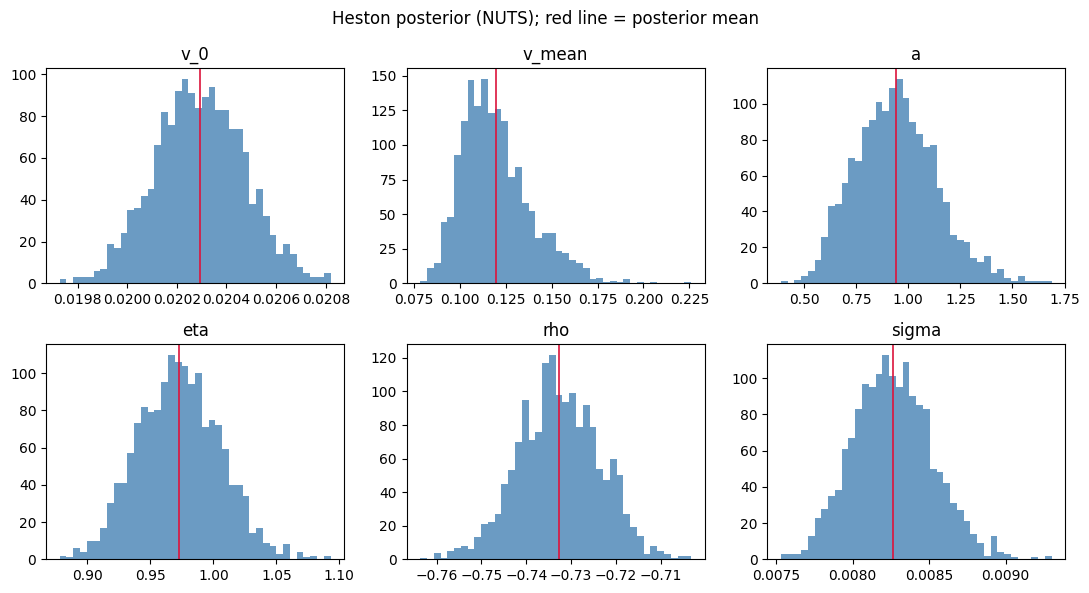

In [8]:
plot_posterior(model.posterior)
plt.show()

## 5. Calibration accuracy — in-sample vs the held-out wing

`svi_iv_rmse` is the **noise floor**: the market interpolant's own residual against the quotes.
Heston is not expected to beat it — a model that did would be fitting quote noise. It is what makes
the Heston number interpretable rather than just a number.

In [9]:
def model_calls(frame: pd.DataFrame) -> np.ndarray:
    return model.call(frame.strike.to_numpy(), s0, r, frame.ttm.to_numpy())


err_train = surface_rmse(train, model_calls(train), r)
err_test = surface_rmse(test, model_calls(test), r)
floor = svi_iv_rmse(clean, surface.svi)

metrics = pd.DataFrame([
    {"set": "train (fitted)", "n": err_train.n_quotes, "iv_rmse": err_train.iv_rmse,
     "iv_mae": err_train.iv_mae, "price_rmse": err_train.price_rmse,
     "price_rel_mae": err_train.price_rel_mae},
    {"set": "test (held-out wing)", "n": err_test.n_quotes, "iv_rmse": err_test.iv_rmse,
     "iv_mae": err_test.iv_mae, "price_rmse": err_test.price_rmse,
     "price_rel_mae": err_test.price_rel_mae},
    {"set": "SVI interpolant (floor)", "n": len(clean), "iv_rmse": floor,
     "iv_mae": np.nan, "price_rmse": np.nan, "price_rel_mae": np.nan},
])
display(metrics.style.format({"iv_rmse": "{:.4f}", "iv_mae": "{:.4f}",
                              "price_rmse": "{:.2f}", "price_rel_mae": "{:.2%}"},
                             na_rep="—"))

print(f"in-sample  IV RMSE : {100 * err_train.iv_rmse:.2f} vol points")
print(f"held-out   IV RMSE : {100 * err_test.iv_rmse:.2f} vol points")
print(f"SVI floor          : {100 * floor:.2f} vol points")

,set,n,iv_rmse,iv_mae,price_rmse,price_rel_mae
0,train (fitted),514,0.0084,0.0059,18.05,4.53%
1,test (held-out wing),176,0.0266,0.0155,3.91,0.31%
2,SVI interpolant (floor),690,0.0052,—,—,—


in-sample  IV RMSE : 0.84 vol points
held-out   IV RMSE : 2.66 vol points
SVI floor          : 0.52 vol points


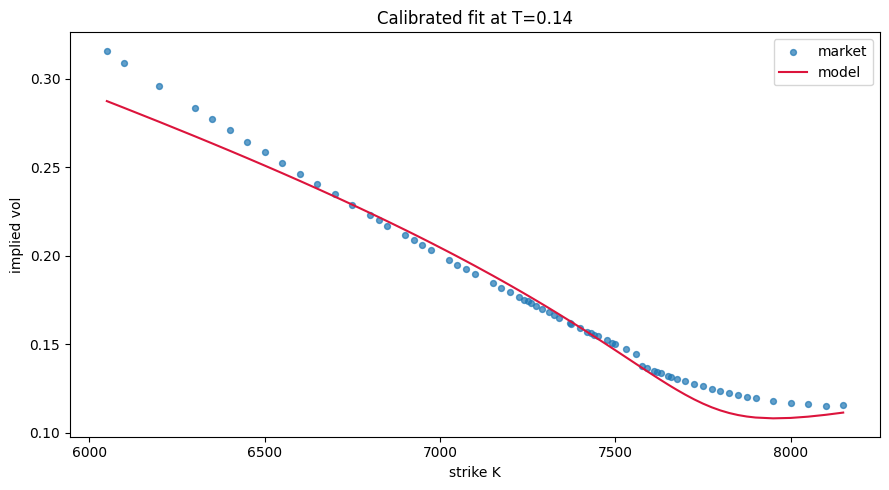

In [10]:
mid_ttm = sorted(clean.ttm.unique())[len(clean.ttm.unique()) // 2]
iv_model = implied_vol(model_calls(clean), clean.forward.to_numpy(),
                       clean.strike.to_numpy(), clean.ttm.to_numpy(), r)

fig, ax = plt.subplots(figsize=(9, 5))
plot_smile_fit(clean, iv_model, ttm=mid_ttm, ax=ax)
fig.tight_layout(); plt.show()

## 6. Monte Carlo — the simulator, checked against the exact pricer

`HestonSimulator` uses **Andersen QE**, not Euler. The calibrated parameters violate Feller (see
above), and that is exactly the regime where Euler full-truncation acquires a visible discretisation
bias — which, since the MC-vs-Fourier gap is itself a reported metric, would show up as fake model
error.

The column to read is **`z_max`** = $\max |{\rm mc} - {\rm exact}| / {\rm stderr}$. An RMSE of
"0.4" means nothing until you know the Monte-Carlo noise: $z \lesssim 3$ is sampling noise,
$z \gg 3$ is real bias. Note this is a max over ~700 quotes, so even under pure noise it sits
around 3.2 — read it as an outlier statistic, not a t-test.

This only became a meaningful check once the reference pricer in §3 was converged: run against the
old $(u_{\max}=200)$ quadrature, `z_max` came out at 6.6 and looked like simulator bias, when it was
really the *reference* that was wrong at the short end.

This simulator is also Phase 3's deep-hedging scenario generator, which is why it returns whole
paths rather than terminal values.

In [11]:
mc_cfg = MCConfig(scheme="qe", n_paths=100_000, steps_per_year=252, seed=0)
sim = HestonSimulator(fitted, mc_cfg)

ttms = sorted(clean.ttm.unique())
paths = sim.simulate(s_0=s0, r=r, maturities=ttms)

mc_price, mc_se = mc_call_prices(paths, clean.strike.to_numpy(), clean.ttm.to_numpy())
reference = model_calls(clean)
mc_err = mc_pricing_error(mc_price, mc_se, reference)

print(f"paths          : {paths.n_paths:,} QE, {len(paths.times) - 1} steps to T={ttms[-1]:.2f}")
print(f"MC price RMSE  : {mc_err.rmse:.4f}   (rel {mc_err.rel_rmse:.2%})")
print(f"mean MC stderr : {mc_err.mean_stderr:.4f}")
print(f"z_max          : {mc_err.z_max:.2f}   "
      f"({'sampling noise' if mc_err.z_max < 3 else 'DISCRETISATION BIAS'})")

paths          : 100,000 QE, 260 steps to T=1.00
MC price RMSE  : 1.0611   (rel 0.43%)
mean MC stderr : 1.0602
z_max          : 1.96   (sampling noise)


### Where the simulator and the pricer disagree

`mc_price_rmse` and `z_max` are summaries; they say *how big* the gap is, not *where*. That
matters because discretisation bias is **structured** — it concentrates at the short maturities
and in the wings, exactly where the QE-vs-Euler choice bites — whereas sampling noise scatters.

The lower panel is the one that decides: inside ±3 the gap is Monte-Carlo noise and the
simulator is consistent with the exact pricer.

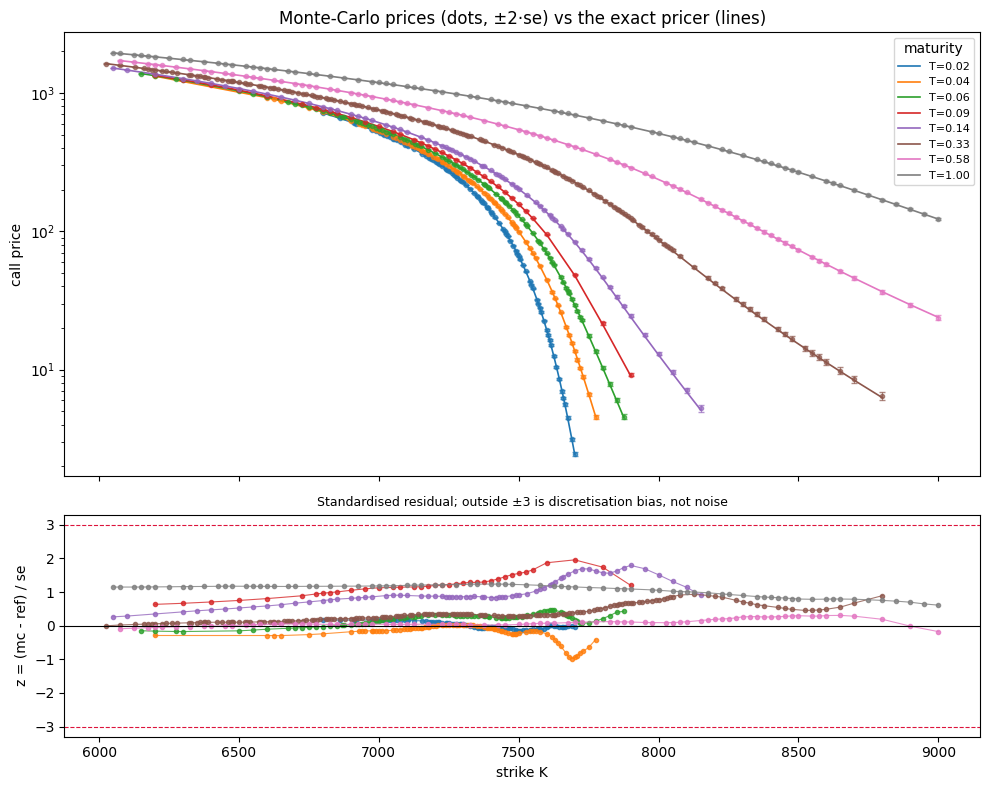

In [12]:
fig = plot_mc_prices(clean, mc_price, mc_se, reference)
plt.show()

### No-arbitrage: is the simulated spot a martingale?

$E[S_T]$ must equal $F = S_0 e^{rT}$. The residual is meaningless without its standard error — at
$S_0 \approx 7500$ and 100k paths, the standard error on $E[S_T]$ is already several index points,
so a raw residual of 10 points is *noise*. `z` is the residual in standard errors; $|z| > 3$ is a
genuine violation.

The simulator deliberately applies **no martingale correction**: rescaling the paths to hit the
forward would drive this metric to zero by construction and make it vacuous.

In [13]:
mart = martingale_residual(paths, ttms)
display(mart.style.format({"ttm": "{:.3f}", "e_s_t": "{:.1f}", "forward": "{:.1f}",
                           "residual": "{:+.2f}", "rel_residual": "{:+.4%}",
                           "stderr": "{:.2f}", "z": "{:+.2f}"}))

print(f"worst |z| : {mart.z.abs().max():.2f}   (|z| > 3 would be a real violation)")

,ttm,e_s_t,forward,residual,rel_residual,stderr,z
0,0.017,7518.9,7518.9,+0.07,+0.0010%,0.45,+0.17
1,0.039,7528.1,7528.3,-0.19,-0.0026%,0.69,-0.28
2,0.063,7538.8,7538.9,-0.10,-0.0013%,0.90,-0.11
3,0.091,7551.4,7550.8,+0.59,+0.0078%,1.10,+0.54
4,0.140,7572.3,7572.1,+0.12,+0.0015%,1.41,+0.08
5,0.332,7654.9,7655.8,-0.88,-0.0115%,2.39,-0.37
6,0.581,7764.5,7765.9,-1.45,-0.0187%,3.45,-0.42
7,1.000,7958.4,7954.7,+3.71,+0.0466%,4.99,+0.74


worst |z| : 0.74   (|z| > 3 would be a real violation)


### Distributional fidelity: Wasserstein against the BL marginals

$W_1$ between the simulated $S_T$ and the Breeden–Litzenberger density extracted in notebook 00 —
the first time the model is scored against the *distribution* rather than against prices.

`tail_mass` is the guard-rail: the BL density lives on the traded strike range, so any simulated
path landing outside it is being compared against a truncated, renormalised distribution. If
`tail_mass` is not small, $W_1$ is measuring the grid, not the model.

In [14]:
bl = [m for m in surface.marginals if any(np.isclose(m.ttm, ttms))]
marg = marginal_report(bl, paths.samples([m.ttm for m in bl]))

display(marg.style.format({"ttm": "{:.3f}", "w1": "{:.1f}", "w1_rel": "{:.4%}",
                           "bl_mean": "{:.0f}", "model_mean": "{:.0f}",
                           "model_stderr": "{:.1f}", "tail_mass": "{:.2%}"}))

print(f"mean W1 (relative) : {marg.w1_rel.mean():.4%}")
print(f"max tail_mass      : {marg.tail_mass.max():.2%}")

,ttm,w1,w1_rel,bl_mean,model_mean,model_stderr,tail_mass
0,0.017,21.8,0.2906%,7504,7519,0.4,6.20%
1,0.039,31.3,0.4173%,7505,7528,0.7,6.91%
2,0.063,38.4,0.5106%,7519,7539,0.9,5.09%
3,0.091,63.1,0.8396%,7521,7551,1.1,8.57%
4,0.140,50.7,0.6706%,7562,7572,1.4,3.57%
5,0.332,83.1,1.0839%,7664,7655,2.4,2.09%
6,0.581,137.9,1.7636%,7820,7764,3.5,3.01%
7,1.000,429.1,5.4308%,7901,7958,5.0,4.71%


mean W1 (relative) : 1.3759%
max tail_mass      : 8.57%


## 7. The process itself

Every number above is a *functional* of the simulated paths — prices at T, E[S_T] against the
forward, W1 against the BL marginals. Not one of them looks at the path between 0 and T. The
process was built in §6 and then never seen; this is the object those numbers came from.

There is no analytical p(S, t) to draw underneath the way there is for Ornstein–Uhlenbeck:
Heston's transition density has no closed form, and Phase 2's neural LSV will have none either.
So the background is the **empirical** density of the same 100k paths, and the red lines are
twelve of those paths drawn over it. It is a self-consistency picture — the validation against
truth is the Fourier comparison in §6, not this.

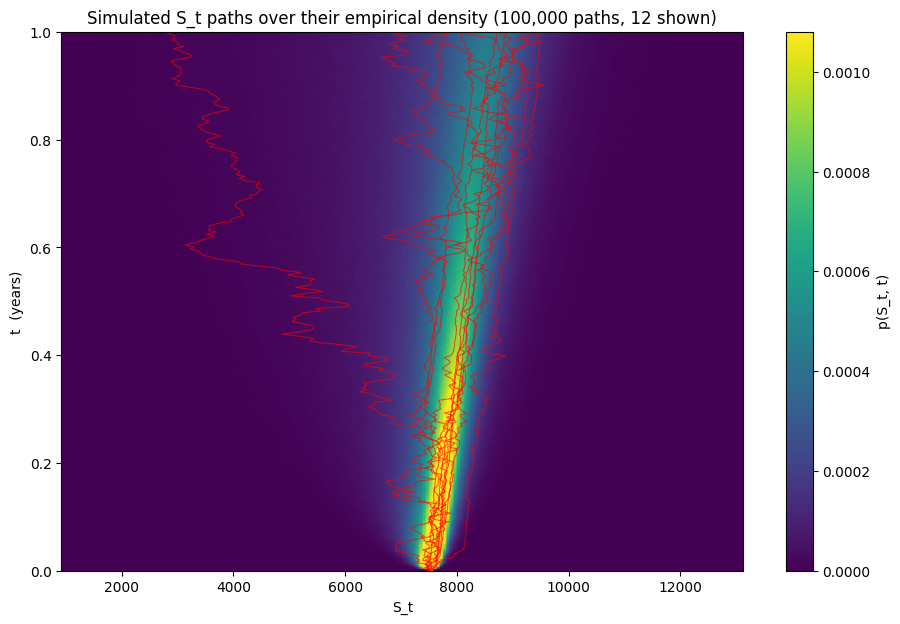

In [15]:
fig = plot_paths_density(paths, n_show=12)
plt.show()

The variance panel is the one to read against the `feller` column. When `2·a·v_mean < eta²` the
density piles up against zero instead of being repelled from it — that is the regime Andersen QE
exists to handle and where Euler full-truncation picks up its bias. The calibrated SPX params
sit in it, so this is a fact about the market rather than a failed fit.

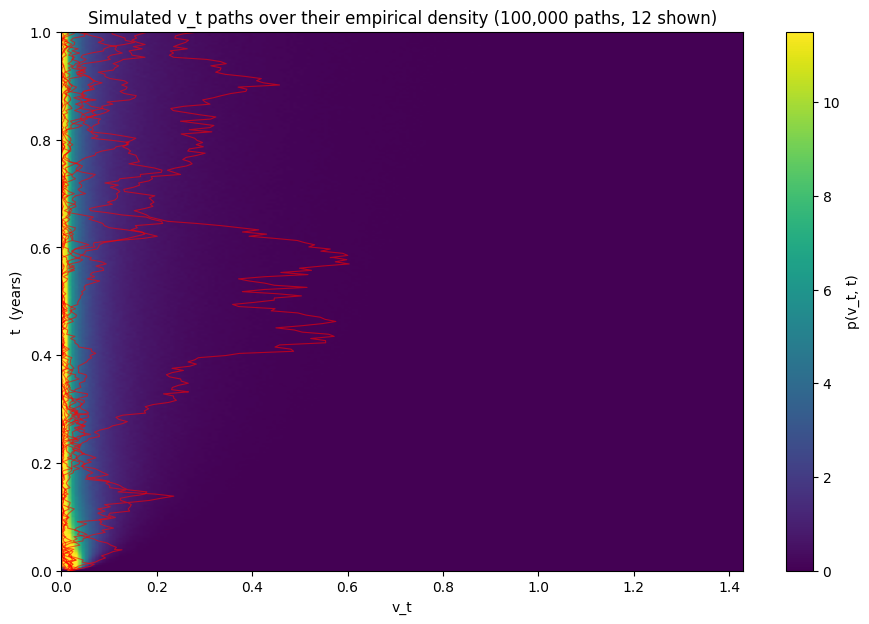

In [16]:
fig = plot_paths_density(paths, kind="variance", n_show=12)
plt.show()

## 8. The benchmark row


In [17]:
row = build_row(
    model="heston-nuts",
    snapshot=snapshot,
    train=err_train,
    test=err_test,
    svi_iv_rmse=floor,
    mc=mc_err,
    marginals=marg,
    martingale=mart,
    feller=fitted.feller(),
    posterior=posterior,
    notes="QE MC 100k paths; wings held out per maturity",
)

# anchor on ROOT: the notebook's cwd is notebooks/, and the table belongs at the repo root
bench_cfg = BenchmarkConfig(csv_path=str(ROOT / "reports/benchmark.csv"),
                            md_path=str(ROOT / "reports/benchmark.md"))
table = BenchmarkTable(bench_cfg).upsert(row)

display(table)
print((ROOT / "reports/benchmark.md").read_text())

,model,snapshot,n_quotes,iv_rmse_train,iv_rmse_test,price_rmse,svi_iv_rmse,w1_rel_mean,mc_price_rmse,mc_price_z_max,martingale_rel_max,feller,r_hat_max,ess_min,divergences,run,notes
0,heston-nuts,2026-06-16,690,0.0084,0.0266,18.0473,0.0052,0.0138,1.0611,1.9566,0.0005,False,1.0074,525.3354,0,,QE MC 100k paths; wings held out per maturity


# QuantFlow benchmark

Generated by `src.eval.benchmark.BenchmarkTable`. Do not edit by hand — edit the
notebook that produces the row and re-run it (`reports/benchmark.csv` is the store).

`iv_rmse_test` is the headline: implied-vol RMSE in absolute vol units on the
**held-out wing** of strikes. `svi_iv_rmse` is the market interpolant's own
in-sample residual — the noise floor a model is not expected to beat.
`mc_price_z_max` > 3 means the MC-vs-Fourier gap is discretisation bias, not noise.

| model | snapshot | n_quotes | iv_rmse_train | iv_rmse_test | price_rmse | svi_iv_rmse | w1_rel_mean | mc_price_rmse | mc_price_z_max | martingale_rel_max | feller | r_hat_max | ess_min | divergences | run | notes |
|---|---|---|---|---|---|---|---|---|---|---|---|---|---|---|---|---|
| heston-nuts | 2026-06-16 | 690 | 0.0084 | 0.0266 | 18.047 | 0.0052 | 0.01376 | 1.0611 | 1.96 | 0.00047 | False | 1.007 | 525 | 0 |  | QE MC 100k paths; wings held out per maturity |



## Where Phase 2 picks this up

The baseline is on the board: Heston, calibrated by NUTS, scored in-sample **and** on a held-out
wing, with its posterior diagnostics, its MC simulator validated against the exact pricer, and its
Wasserstein distance to the BL marginals — all in `reports/benchmark.md`.

Phase 2 replaces the model and *nothing else*: same cleaned surface, same wing split, same
`src/eval` functions, same table. That is what makes the comparison mean something.